# Sephora Product Intelligence — Exploratory Data Analysis

## Project Overview
This notebook is the first stage of a full BI pipeline analyzing 8,000+ Sephora products 
and 1M+ skincare reviews. The goal is to identify which products are genuinely worth buying 
by building a composite "worth the hype" score from review quality, pricing, and ingredient data.

## Business Questions
- Which products are most worth the hype?
- Which brands have the best review quality?
- Are expensive products actually rated better?
- Which categories have the highest satisfaction?
- Which products are overrated vs underrated?

## Data Sources
- `product_info.csv` — 8,000+ products with pricing, ingredients, brand, and category info
- `reviews_*.csv` — ~1M user reviews with ratings, skin type, helpfulness scores

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


## 2. Load Data

In [2]:
# Load products
products = pd.read_csv("../data/raw/product_info.csv")

# Load all review files and combine
review_files = glob.glob("../data/raw/reviews_*.csv")
reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)

print(f"Products shape: {products.shape}")
print(f"Reviews shape: {reviews.shape}")
print(f"Review files loaded: {len(review_files)}")

Products shape: (8494, 27)
Reviews shape: (1094411, 19)
Review files loaded: 5


## 3. First Look at the Data

In [4]:
# Quick look at products
print("=== PRODUCTS ===")
print(products.dtypes)
products.head(3)

=== PRODUCTS ===
product_id             object
product_name           object
brand_id                int64
brand_name             object
loves_count             int64
rating                float64
reviews               float64
size                   object
variation_type         object
variation_value        object
variation_desc         object
ingredients            object
price_usd             float64
value_price_usd       float64
sale_price_usd        float64
limited_edition         int64
new                     int64
online_only             int64
out_of_stock            int64
sephora_exclusive       int64
highlights             object
primary_category       object
secondary_category     object
tertiary_category      object
child_count             int64
child_max_price       float64
child_min_price       float64
dtype: object


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.64,11.00,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.00,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.15,13.00,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.00,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.00,30.00
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.25,16.00,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.00,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.00,30.00


In [5]:
# Quick look at reviews
print("=== REVIEWS ===")
print(reviews.dtypes)
reviews.head(3)

=== REVIEWS ===
Unnamed: 0                    int64
author_id                    object
rating                        int64
is_recommended              float64
helpfulness                 float64
total_feedback_count          int64
total_neg_feedback_count      int64
total_pos_feedback_count      int64
submission_time              object
review_text                  object
review_title                 object
skin_tone                    object
eye_color                    object
skin_type                    object
hair_color                   object
product_id                   object
product_name                 object
brand_name                   object
price_usd                   float64
dtype: object


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.00,1.00,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.00
1,1,31423088263,1,0.00,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.00
2,2,5061282401,5,1.00,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.00


## 4. Data Validation
Before cleaning anything, we document what's broken. This is standard BI practice — 
understand the problem before fixing it.

In [6]:
print("=== PRODUCT MISSING VALUES ===")
product_nulls = products.isnull().sum()
product_null_pct = (products.isnull().sum() / len(products) * 100).round(1)
product_null_df = pd.DataFrame({
    "missing_count": product_nulls,
    "missing_pct": product_null_pct
})
print(product_null_df[product_null_df["missing_count"] > 0].sort_values("missing_pct", ascending=False))

=== PRODUCT MISSING VALUES ===
                    missing_count  missing_pct
sale_price_usd               8224        96.80
value_price_usd              8043        94.70
variation_desc               7244        85.30
child_max_price              5740        67.60
child_min_price              5740        67.60
highlights                   2207        26.00
size                         1631        19.20
variation_value              1598        18.80
variation_type               1444        17.00
tertiary_category             990        11.70
ingredients                   945        11.10
rating                        278         3.30
reviews                       278         3.30
secondary_category              8         0.10


In [7]:
print("=== REVIEW MISSING VALUES ===")
review_nulls = reviews.isnull().sum()
review_null_pct = (reviews.isnull().sum() / len(reviews) * 100).round(1)
review_null_df = pd.DataFrame({
    "missing_count": review_nulls,
    "missing_pct": review_null_pct
})
print(review_null_df[review_null_df["missing_count"] > 0].sort_values("missing_pct", ascending=False))

=== REVIEW MISSING VALUES ===
                missing_count  missing_pct
helpfulness            561592        51.30
review_title           310654        28.40
hair_color             226768        20.70
eye_color              209628        19.20
skin_tone              170539        15.60
is_recommended         167988        15.30
skin_type              111557        10.20
review_text              1444         0.10


In [8]:
print("=== DUPLICATE CHECKS ===")
print(f"Duplicate products: {products.duplicated(subset=['product_id']).sum()}")
print(f"Duplicate reviews: {reviews.duplicated().sum()}")

print("\n=== RATING VALIDITY ===")
print(f"Reviews with valid rating (1-5): {reviews['rating'].between(1,5).mean()*100:.1f}%")
print(f"Products with missing rating: {products['rating'].isnull().sum()}")

print("\n=== BASIC STATS ===")
print(f"Unique brands: {products['brand_name'].nunique()}")
print(f"Unique categories: {products['primary_category'].nunique()}")
print(f"Price range: ${products['price_usd'].min():.2f} - ${products['price_usd'].max():.2f}")
print(f"Average product rating: {products['rating'].mean():.2f}")

=== DUPLICATE CHECKS ===
Duplicate products: 0
Duplicate reviews: 0

=== RATING VALIDITY ===
Reviews with valid rating (1-5): 100.0%
Products with missing rating: 278

=== BASIC STATS ===
Unique brands: 304
Unique categories: 9
Price range: $3.00 - $1900.00
Average product rating: 4.19


### Validation Findings

- **No duplicates** found in either products or reviews — data is clean at the ID level
- **All 1,094,411 review ratings are valid** (between 1-5) — no bad data to filter
- **278 products have no rating** — these will be excluded from scoring but kept in the dataset
- `sale_price_usd` (96.8% missing) and `value_price_usd` (94.7% missing) will be dropped entirely
- `helpfulness` is 51.3% missing — we'll use it where available but won't rely on it as a core metric
- Skin profile columns (skin_tone, skin_type, hair, eye) are 10-20% missing — acceptable for segmentation
- **304 unique brands**, **9 primary categories**, prices ranging from **$3 to $1,900**
- Average product rating is **4.19 out of 5** — typical of review platforms where satisfied customers review more

## 5. Category & Brand Exploration
Before cleaning, we explore what categories and brands exist to make informed decisions 
about what to keep and what to exclude.

In [9]:
print("=== PRIMARY CATEGORIES ===")
cat_counts = products["primary_category"].value_counts()
print(cat_counts)

=== PRIMARY CATEGORIES ===
primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64


In [10]:
print("=== TOP 20 BRANDS BY PRODUCT COUNT ===")
brand_counts = products["brand_name"].value_counts().head(20)
print(brand_counts)

=== TOP 20 BRANDS BY PRODUCT COUNT ===
brand_name
SEPHORA COLLECTION         352
CLINIQUE                   179
Dior                       136
tarte                      131
NEST New York              115
Bumble and bumble          110
Kérastase                  108
TOM FORD                   100
Charlotte Tilbury           99
Anastasia Beverly Hills     95
Oribe                       94
Moroccanoil                 91
Jo Malone London            88
Hourglass                   87
Fenty Beauty by Rihanna     82
Lancôme                     81
Kiehl's Since 1851          75
MAKE UP FOR EVER            74
Benefit Cosmetics           74
Drybar                      72
Name: count, dtype: int64


In [11]:
print("=== SECONDARY CATEGORIES (top 30) ===")
print(products["secondary_category"].value_counts().head(30))

=== SECONDARY CATEGORIES (top 30) ===
secondary_category
Women                        875
Hair Styling & Treatments    757
Eye                          711
Face                         659
Moisturizers                 551
Value & Gift Sets            498
Treatments                   466
Shampoo & Conditioner        431
Lip                          411
Cleansers                    361
Candles & Home Scents        263
Brushes & Applicators        246
Body Moisturizers            220
Mini Size                    187
Eye Care                     186
Masks                        166
Cheek                        165
Tools                        153
Makeup                       137
Men                          135
Sunscreen                    109
Skincare                      98
Bath & Shower                 84
High Tech Tools               80
Wellness                      79
Body Care                     69
Self Tanners                  64
Lip Balms & Treatments        61
Hair               

### Category & Brand Findings

**Primary categories (9 total):**
- Dataset is dominated by **Skincare** (2,420) and **Makeup** (2,369) — together nearly 57% of all products
- **Hair** (1,464) and **Fragrance** (1,432) are strong secondary categories
- **Mini Size** (288) is a category itself — these are travel/sample sizes of other products, worth filtering out or flagging separately
- **Gifts** (4) and **Tools & Brushes** (52) are too small to analyze meaningfully on their own

**Secondary categories:**
- "Women" (875) under Fragrance is the largest secondary — just means women's fragrance
- Skincare secondaries are rich: Moisturizers, Treatments, Cleansers, Masks, Sunscreen, Eye Care — enough for individual sub-analysis
- "Candles & Home Scents" (263) appears under Fragrance — not a beauty product, we'll flag these

**Brands:**
- SEPHORA COLLECTION dominates with 352 products — nearly 2x the next brand (Clinique 179)
- Strong mix of luxury (Dior, TOM FORD, Jo Malone) and mass-prestige (tarte, Charlotte Tilbury, Fenty)
- Top 20 brands are primarily Skincare, Makeup, and Hair — matches category distribution

**Decisions for analysis:**
- Primary focus: **Skincare** and **Makeup** — largest categories with most review data
- Secondary focus: **Hair** and **Fragrance**
- Flag and separate: Mini Size products, Gifts, Candles & Home Scents

## 6. Rating & Price Distributions
Visualizing how ratings and prices are spread across the dataset. This tells us whether 
the data is skewed, where most products cluster, and whether price correlates with quality.

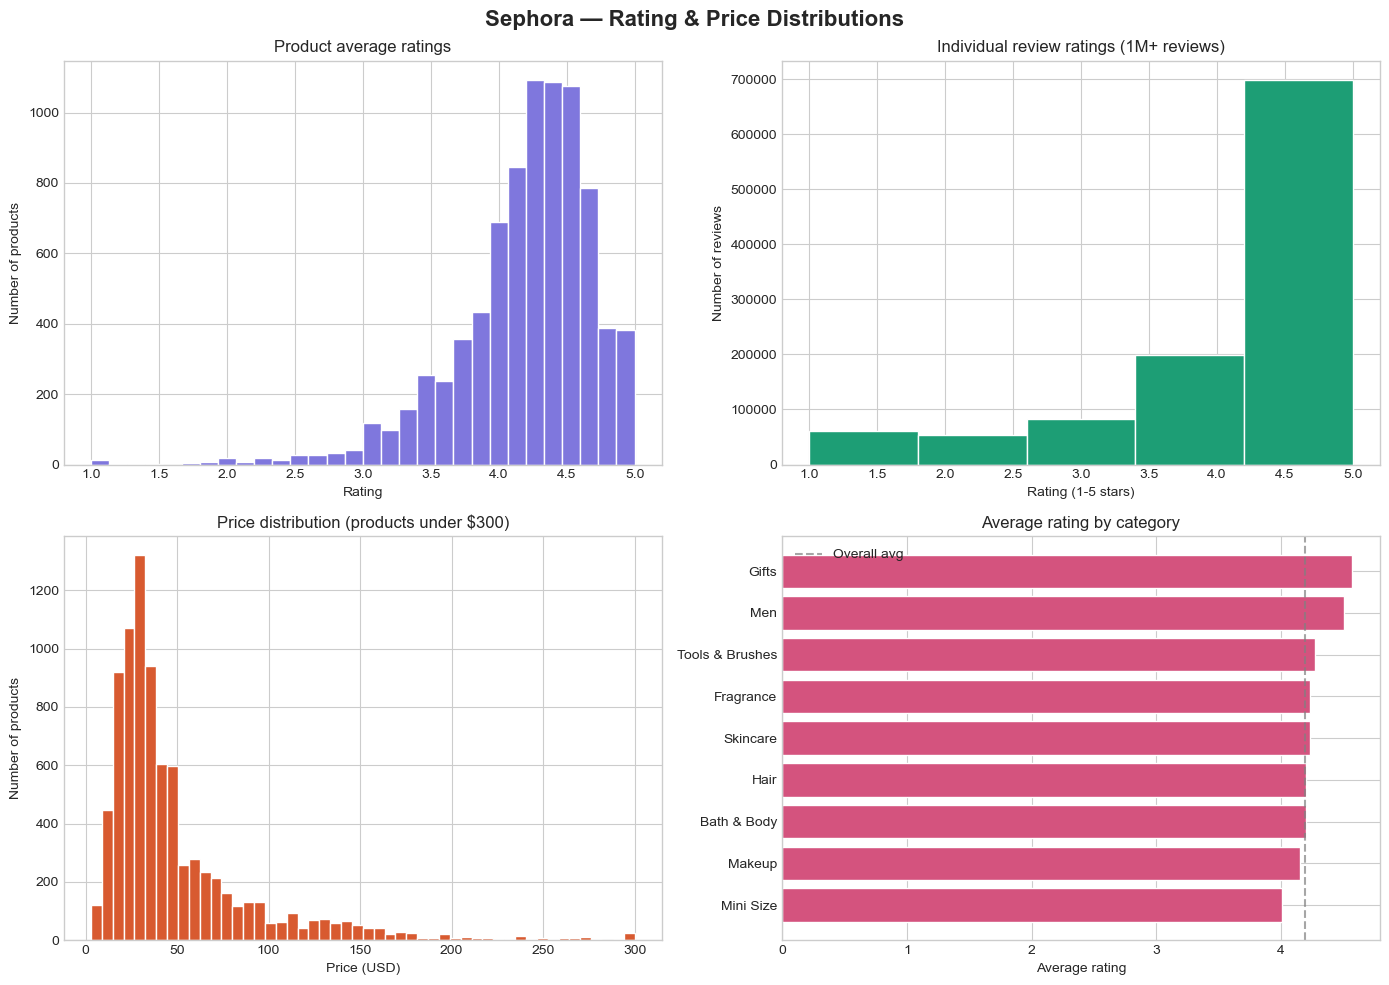

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sephora — Rating & Price Distributions", fontsize=16, fontweight="bold")

# Plot 1: Product-level rating distribution
axes[0, 0].hist(products["rating"].dropna(), bins=30, color="#7F77DD", edgecolor="white")
axes[0, 0].set_title("Product average ratings")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Number of products")

# Plot 2: Individual review rating distribution
axes[0, 1].hist(reviews["rating"], bins=5, color="#1D9E75", edgecolor="white")
axes[0, 1].set_title("Individual review ratings (1M+ reviews)")
axes[0, 1].set_xlabel("Rating (1-5 stars)")
axes[0, 1].set_ylabel("Number of reviews")

# Plot 3: Price distribution (capped at $300 so we can see the bulk)
price_filtered = products[products["price_usd"] <= 300]["price_usd"]
axes[1, 0].hist(price_filtered, bins=50, color="#D85A30", edgecolor="white")
axes[1, 0].set_title("Price distribution (products under $300)")
axes[1, 0].set_xlabel("Price (USD)")
axes[1, 0].set_ylabel("Number of products")

# Plot 4: Average rating by primary category
cat_ratings = products.groupby("primary_category")["rating"].mean().sort_values(ascending=True)
axes[1, 1].barh(cat_ratings.index, cat_ratings.values, color="#D4537E", edgecolor="white")
axes[1, 1].set_title("Average rating by category")
axes[1, 1].set_xlabel("Average rating")
axes[1, 1].axvline(x=products["rating"].mean(), color="gray", linestyle="--", alpha=0.7, label="Overall avg")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Rating & Price Distribution Findings

**Rating distributions:**
- Product ratings are heavily left-skewed — the majority cluster between 4.0 and 4.7 out of 5
- Nearly 700,000 of 1M+ individual reviews are 5-star — a classic e-commerce positivity bias 
  where satisfied customers review more than dissatisfied ones
- Very few products average below 3.0 — poor products are likely removed or rarely reviewed
- This skew means raw average rating alone is a weak signal — we need volume, 
  5-star share, and price context to identify truly standout products

**Price distribution:**
- Most products price between 20–75, peaking around 25–35
- Long right tail extends to $1,900 -luxury outliers will need handling in our scoring
- The 20–50 dollar range is Sephora's mass-prestige core and where most purchase decisions happen

**Category ratings:**
- All 9 categories average between 4.0–4.5 — remarkably consistent
- No single category dramatically outperforms or underperforms
- Gifts rate highest (small sample, n=4 — statistically unreliable)
- Mini Size rates lowest — possibly because travel sizes underdeliver vs full size expectations

**Implication for our model:**
- Because ratings are compressed in a narrow range (4.0–4.7), small differences matter a lot
- A product averaging 4.6 vs 4.2 with 500+ reviews is a meaningful signal
- We must combine rating WITH review volume and price to build a meaningful worth-the-hype score

## 7. Price vs Rating Analysis
Does paying more actually get you a better product? This is one of our core business 
questions. We'll plot every product as a dot — price on x axis, rating on y axis — 
to see if any relationship exists.

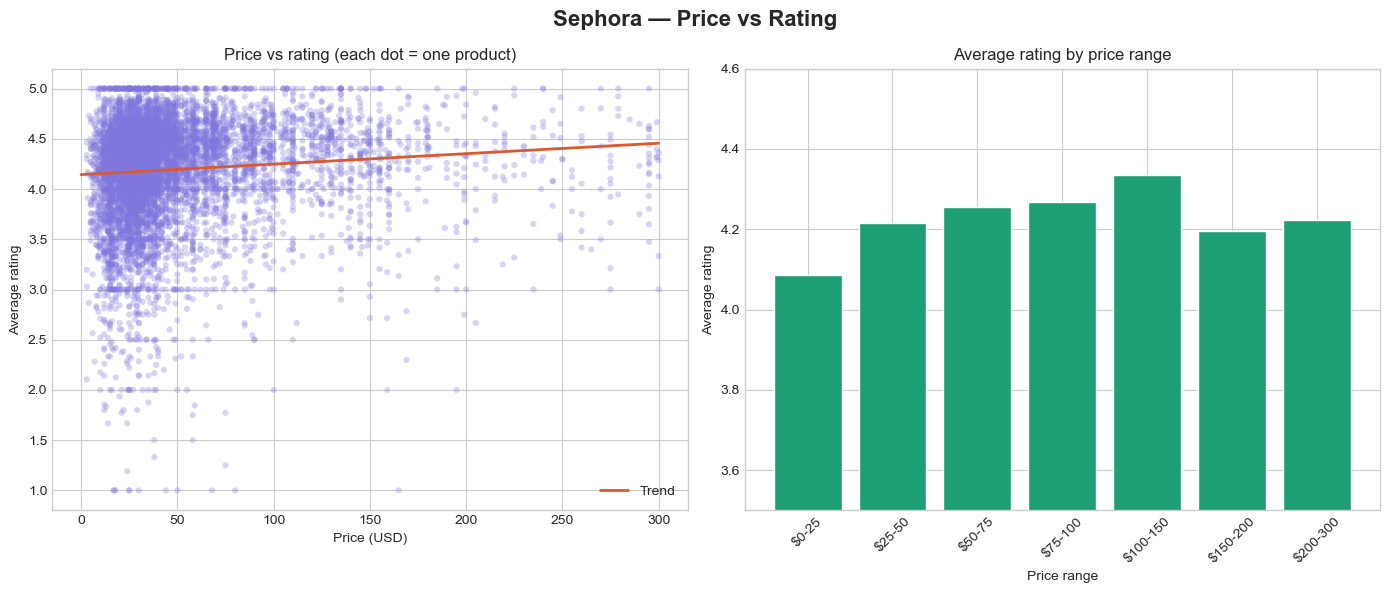

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Sephora — Price vs Rating", fontsize=16, fontweight="bold")

# Plot 1: Scatter plot price vs rating
products_clean = products.dropna(subset=["price_usd", "rating"])
products_clean = products_clean[products_clean["price_usd"] <= 300]

axes[0].scatter(
    products_clean["price_usd"],
    products_clean["rating"],
    alpha=0.3,
    color="#7F77DD",
    edgecolors="none",
    s=20
)
axes[0].set_title("Price vs rating (each dot = one product)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Average rating")

# Add a trend line
z = np.polyfit(products_clean["price_usd"], products_clean["rating"], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 300, 100)
axes[0].plot(x_line, p(x_line), color="#D85A30", linewidth=2, label="Trend")
axes[0].legend()

# Plot 2: Average rating by price bucket
products_clean["price_bucket"] = pd.cut(
    products_clean["price_usd"],
    bins=[0, 25, 50, 75, 100, 150, 200, 300],
    labels=["$0-25", "$25-50", "$50-75", "$75-100", "$100-150", "$150-200", "$200-300"]
)

bucket_ratings = products_clean.groupby("price_bucket", observed=True)["rating"].mean()

axes[1].bar(bucket_ratings.index, bucket_ratings.values, color="#1D9E75", edgecolor="white")
axes[1].set_title("Average rating by price range")
axes[1].set_xlabel("Price range")
axes[1].set_ylabel("Average rating")
axes[1].set_ylim(3.5, 4.6)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Price vs Rating Findings

**Does price predict quality? Weakly — but not how you'd expect.**

- The trend line is nearly flat — price alone is a very poor predictor of rating
- The scatter plot shows ratings spread across the full 1–5 range at almost every price point,
  meaning you can find excellent and terrible products at any budget
- Expensive products (150+) show less variance — they rarely get very low ratings, 
  suggesting luxury brands maintain a minimum quality floor
- The $0–25 budget tier actually averages the lowest rating (4.09) — 
  cheap products slightly underperform

**The sweet spot is 75–150:**
- This range averages the highest ratings (4.25–4.32)
- Beyond $150, ratings actually dip slightly — you start paying for brand prestige 
  rather than product performance
- This is a key insight for our "worth the hype" score — high price should 
  slightly penalize a product's score, not reward it

**Implication:**
- Price and rating have a weak, non-linear relationship
- A 30 product rated 4.6 with 500 reviews is likely more "worth it" than 
  a 200 product rated 4.3 with 50 reviews
- This validates our worth-the-hype formula that penalizes high price rank

## 8. Brand Performance Analysis
Which brands consistently deliver the best rated products? We look at brands with 
enough products to be statistically meaningful — small brands with 1-2 products 
can have artificially perfect scores.

In [17]:
# Only include brands with at least 10 products for statistical reliability
brand_stats = products.groupby("brand_name").agg(
    avg_rating=("rating", "mean"),
    total_products=("product_id", "count"),
    avg_price=("price_usd", "mean"),
    median_price=("price_usd", "median"),
    avg_loves=("loves_count", "mean")
).reset_index()

brand_stats = brand_stats[brand_stats["total_products"] >= 10].sort_values("avg_rating", ascending=False)

print(f"Brands with 10+ products: {len(brand_stats)}")
print("\n=== TOP 15 BRANDS BY AVERAGE RATING ===")
print(brand_stats.head(15)[["brand_name", "avg_rating", "total_products", "avg_price"]].to_string(index=False))

print("\n=== BOTTOM 10 BRANDS BY AVERAGE RATING ===")
print(brand_stats.tail(10)[["brand_name", "avg_rating", "total_products", "avg_price"]].to_string(index=False))

Brands with 10+ products: 225

=== TOP 15 BRANDS BY AVERAGE RATING ===
       brand_name  avg_rating  total_products  avg_price
             MARA        4.82              10      65.80
       BondiBoost        4.78              34      28.62
      Kate McLeod        4.75              12      31.25
            maude        4.74              12      32.67
         Nutrafol        4.72              10      70.50
       StriVectin        4.66              25      68.12
     Grace Eleyae        4.65              10      27.00
          FaceGym        4.65              19      80.58
     alpyn beauty        4.64              13      44.85
Saint Jane Beauty        4.63              10      62.80
      The Nue Co.        4.59              12      50.67
        Curlsmith        4.57              51      31.35
          RANAVAT        4.56              13      66.77
    Bon Parfumeur        4.55              17      68.94
     Crown Affair        4.54              12      44.17

=== BOTTOM 10 BR

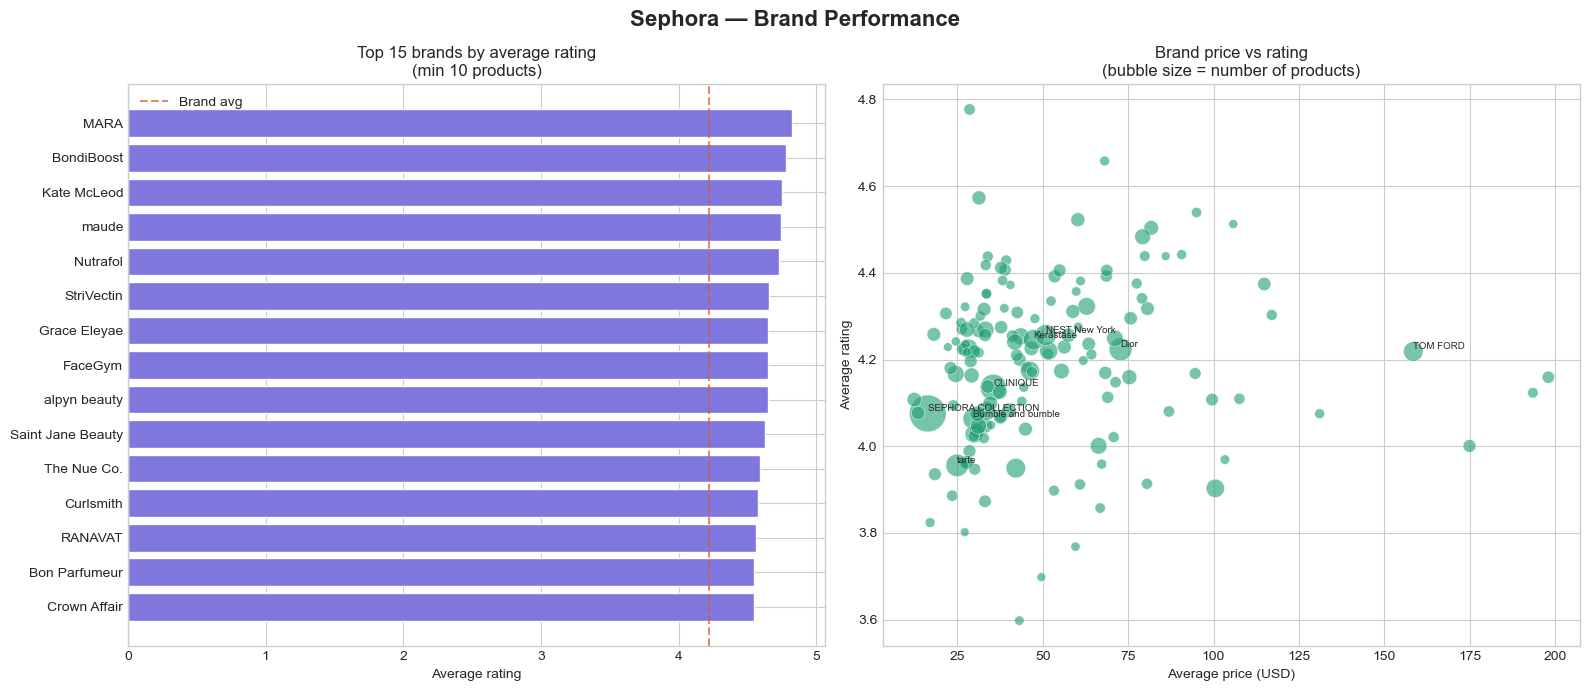

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Sephora — Brand Performance", fontsize=16, fontweight="bold")

# Plot 1: Top 15 brands by rating
top_brands = brand_stats.head(15)
axes[0].barh(top_brands["brand_name"], top_brands["avg_rating"], color="#7F77DD", edgecolor="white")
axes[0].set_title("Top 15 brands by average rating\n(min 10 products)")
axes[0].set_xlabel("Average rating")
axes[0].axvline(x=brand_stats["avg_rating"].mean(), color="#D85A30", linestyle="--", alpha=0.7, label="Brand avg")
axes[0].legend()
axes[0].invert_yaxis()

# Plot 2: Price vs rating bubble chart by brand (top 30 brands by product count)
top30 = products.groupby("brand_name").filter(lambda x: len(x) >= 20)
brand_bubble = top30.groupby("brand_name").agg(
    avg_rating=("rating", "mean"),
    avg_price=("price_usd", "mean"),
    total_products=("product_id", "count")
).reset_index().dropna()

scatter = axes[1].scatter(
    brand_bubble["avg_price"],
    brand_bubble["avg_rating"],
    s=brand_bubble["total_products"] * 2,
    alpha=0.6,
    color="#1D9E75",
    edgecolors="white",
    linewidth=0.5
)

# Label a few notable brands
for _, row in brand_bubble.nlargest(8, "total_products").iterrows():
    axes[1].annotate(
        row["brand_name"],
        (row["avg_price"], row["avg_rating"]),
        fontsize=7,
         ha="left",
        va="bottom"
    )

axes[1].set_title("Brand price vs rating\n(bubble size = number of products)")
axes[1].set_xlabel("Average price (USD)")
axes[1].set_ylabel("Average rating")

plt.tight_layout()
plt.show()

### Brand Performance Findings

**Top performing brands (10+ products):**
- MARA (4.82), BondiBoost (4.78), and Kate McLeod (4.75) lead overall
- Most top-rated brands are **mid-price ($27–$80)** — not luxury tier
- BondiBoost and Curlsmith are the most reliable top performers by volume 
  (34 and 51 products respectively) — harder to fake a high average at scale
- Many top brands are niche/indie — smaller focused ranges tend to outperform 
  large sprawling catalogs

**Bottom performing brands:**
- NuFACE rates worst (3.54) and is the most expensive bottom brand ($288 avg) — 
  classic overrated premium positioning
- FORVR Mood (3.60), Slip (3.63), INC.redible (3.69) all underperform significantly
- The Maker has NaN rating despite 10 products — likely all unreviewed, worth flagging

**Bubble chart insights:**
- SEPHORA COLLECTION — biggest catalog (352 products) but only average rating (4.1) — 
  quantity over quality
- TOM FORD — far right at ~175 avg price, rates only 4.2 — paying for prestige not performance
- tarte — large brand, affordable, but underperforming at ~4.0 — 
  high marketing, mediocre delivery
- Sweet spot brands cluster in the $25–75 range with 4.2–4.5 ratings

**Key insight:**
- Brand size and price do NOT guarantee quality
- The best value brands are mid-price, focused, and often indie
- This directly feeds into our overrated vs underrated analysis later

## 9. Category Deep Dive — What Do We Keep?
Before moving to cleaning, we need to decide which categories and subcategories 
are relevant to our analysis. The dataset covers all of Sephora — not just skincare.
We need to make deliberate choices about scope.

In [19]:
print("=== SKINCARE SECONDARY CATEGORIES ===")
skincare = products[products["primary_category"] == "Skincare"]
print(skincare["secondary_category"].value_counts())

print("\n=== MAKEUP SECONDARY CATEGORIES ===")
makeup = products[products["primary_category"] == "Makeup"]
print(makeup["secondary_category"].value_counts())

print("\n=== HAIR SECONDARY CATEGORIES ===")
hair = products[products["primary_category"] == "Hair"]
print(hair["secondary_category"].value_counts())

=== SKINCARE SECONDARY CATEGORIES ===
secondary_category
Moisturizers              551
Treatments                466
Cleansers                 361
Value & Gift Sets         196
Eye Care                  186
Masks                     166
Mini Size                 112
Sunscreen                 108
High Tech Tools            80
Wellness                   79
Lip Balms & Treatments     61
Self Tanners               53
Shop by Concern             1
Name: count, dtype: int64

=== MAKEUP SECONDARY CATEGORIES ===
secondary_category
Eye                      711
Face                     659
Lip                      411
Brushes & Applicators    233
Cheek                    165
Nail                      52
Accessories               45
Mini Size                 37
Value & Gift Sets         36
Makeup Palettes           20
Name: count, dtype: int64

=== HAIR SECONDARY CATEGORIES ===
secondary_category
Hair Styling & Treatments    757
Shampoo & Conditioner        431
Tools                        153
Va

In [20]:
# Define what we keep
keep_skincare = [
    "Moisturizers", "Treatments", "Cleansers", "Eye Care",
    "Masks", "Sunscreen", "Lip Balms & Treatments", "Self Tanners"
]

keep_makeup = [
    "Eye", "Face", "Lip", "Cheek", "Nail", "Makeup Palettes"
]

keep_hair = [
    "Hair Styling & Treatments", "Shampoo & Conditioner"
]

# Count how many products survive our filter
filtered = products[
    ((products["primary_category"] == "Skincare") & (products["secondary_category"].isin(keep_skincare))) |
    ((products["primary_category"] == "Makeup") & (products["secondary_category"].isin(keep_makeup))) |
    ((products["primary_category"] == "Hair") & (products["secondary_category"].isin(keep_hair)))
]

print(f"Products before filter: {len(products)}")
print(f"Products after filter: {len(filtered)}")
print(f"Products removed: {len(products) - len(filtered)}")
print(f"\nFiltered breakdown by category:")
print(filtered["primary_category"].value_counts())
print(f"\nFiltered breakdown by secondary category:")
print(filtered["secondary_category"].value_counts())

Products before filter: 8494
Products after filter: 5158
Products removed: 3336

Filtered breakdown by category:
primary_category
Makeup      2018
Skincare    1952
Hair        1188
Name: count, dtype: int64

Filtered breakdown by secondary category:
secondary_category
Hair Styling & Treatments    757
Eye                          711
Face                         659
Moisturizers                 551
Treatments                   466
Shampoo & Conditioner        431
Lip                          411
Cleansers                    361
Eye Care                     186
Masks                        166
Cheek                        165
Sunscreen                    108
Lip Balms & Treatments        61
Self Tanners                  53
Nail                          52
Makeup Palettes               20
Name: count, dtype: int64


### Category Scope Decision — Final

We are narrowing our analysis to 3 primary categories and 16 secondary categories 
that represent actual purchasable beauty products with meaningful ingredients and reviews.

**Included:**
- Skincare: Moisturizers, Treatments, Cleansers, Eye Care, Masks, 
  Sunscreen, Lip Balms & Treatments, Self Tanners
- Makeup: Eye, Face, Lip, Cheek, Nail, Makeup Palettes
- Hair: Hair Styling & Treatments, Shampoo & Conditioner

**Excluded and why:**
- Mini Size — travel sizes inflate product count and distort price comparisons
- Value & Gift Sets — bundles distort pricing and ingredient analysis
- High Tech Tools / Tools / Brushes & Applicators — devices, not beauty products
- Wellness — supplements and ingestibles, out of scope
- Accessories — out of scope
- Shop by Concern — navigational tags, not real categories (1–4 products)
- Fragrance — no ingredient transparency, scoring not meaningful

**EDA is now complete. Next step: cleaning notebook where we execute 
these decisions and prepare data for feature engineering.**